In [ ]:
import pandas as pd

In [ ]:
heart_data=pd.read_csv('/content/Heart_Disease_Dataset.csv')

In [ ]:
heart_data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [ ]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [ ]:
heart_data.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [ ]:
heart_data.shape

(1025, 14)

In [ ]:
heart_data.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholestoral,0
fasting_blood_sugar,0
rest_ecg,0
Max_heart_rate,0
exercise_induced_angina,0
oldpeak,0


In [ ]:
heart_data.duplicated().sum()

np.int64(723)

In [ ]:
duplicates = heart_data[heart_data.duplicated()]

In [ ]:
heart_data.drop_duplicates(inplace=True)

In [ ]:
heart_data.duplicated().sum()

np.int64(0)

In [ ]:
heart_data.dtypes

,0
age,int64
sex,object
chest_pain_type,object
resting_blood_pressure,int64
cholestoral,int64
fasting_blood_sugar,object
rest_ecg,object
Max_heart_rate,int64
exercise_induced_angina,object
oldpeak,float64


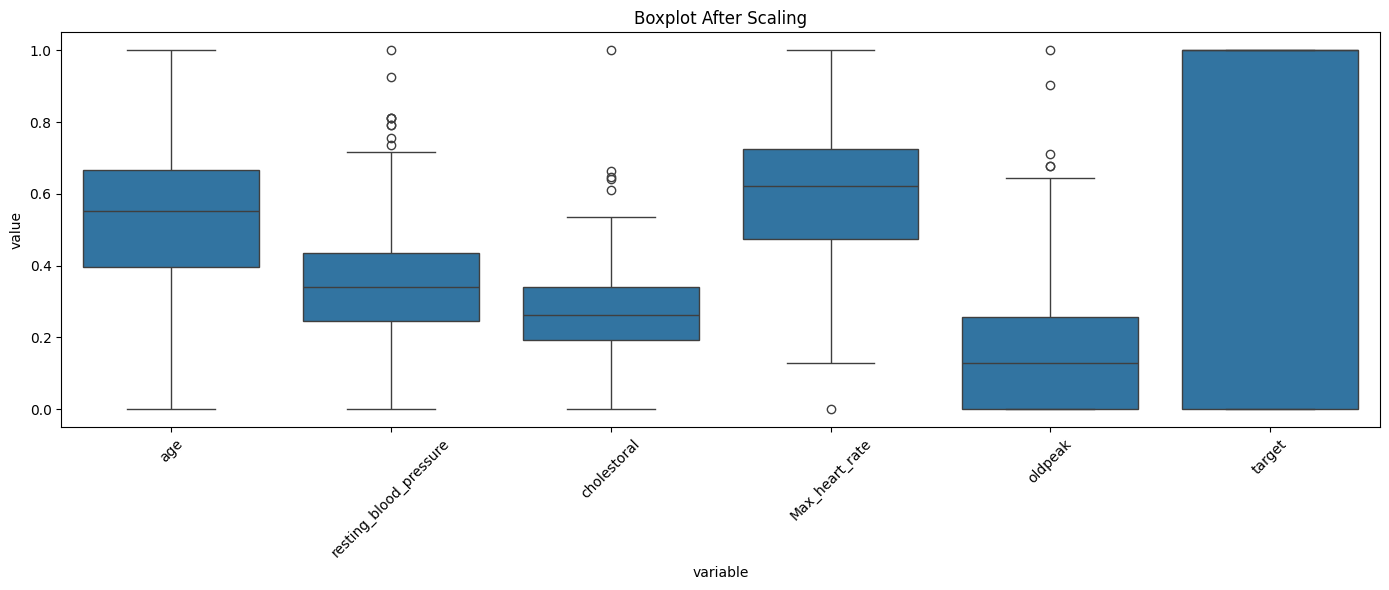

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

num_data = heart_data.select_dtypes(include=['number'])

scaler = MinMaxScaler()
scaled = scaler.fit_transform(num_data)

scaled_df = pd.DataFrame(scaled, columns=num_data.columns)

# Melt for better visualization
melted = scaled_df.melt()

plt.figure(figsize=(14,6))
sns.boxplot(x='variable', y='value', data=melted)

plt.xticks(rotation=45)
plt.title("Boxplot After Scaling")
plt.tight_layout()
plt.show()

In [ ]:
colum=heart_data.columns
print(colum)

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia', 'target'],
      dtype='object')


In [ ]:
numeric_cols = heart_data.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = heart_data[col].quantile(0.25)
    Q3 = heart_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = heart_data[(heart_data[col] < lower) | (heart_data[col] > upper)]

    print(col, ":", len(outliers))

age : 0
resting_blood_pressure : 9
cholestoral : 5
Max_heart_rate : 1
oldpeak : 5
target : 0


In [ ]:
from sklearn.model_selection import train_test_split

# Drop the 'Unnamed: 32' column as it contains all NaN values
# This column was not found in heart_data, so this comment is left as a placeholder.

X = heart_data.drop('target', axis=1)
y = heart_data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic regression


In [ ]:
from sklearn.linear_model import LogisticRegression

def train_logistic_batch(configs):
    models = []

    for cfg in configs:
        model = LogisticRegression(**cfg)
        model.fit(X_train, y_train)

        models.append((model, cfg))

    return models

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.metrics import make_scorer, f1_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

# =========================================
# Preprocessing: One-Hot Encode Categorical Features
# =========================================
# Identify categorical columns from the heart_data info (excluding 'target' which was already dropped)
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to X_train and X_test
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistency between train and test sets after one-hot encoding
X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)

# =========================================
# 1. Parameter Grid
# =========================================
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"],
    "solver": ["liblinear"],
    "max_iter": [1000, 3000, 5000]
}

# =========================================
# 2. Custom F1 Scorer
# =========================================
f1_scorer = make_scorer(f1_score, pos_label=1, average='binary') # Changed pos_label to 1 for binary classification

# =========================================
# 3. GridSearchCV
# =========================================
grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring=f1_scorer
)

grid.fit(X_train, y_train)

# =========================================
# 4. Convert Results
# =========================================
results = pd.DataFrame(grid.cv_results_)

results = results.rename(columns={
    "param_C": "C",
    "param_penalty": "Penalty",
    "param_class_weight": "ClassWeight",
    "param_max_iter": "Iterations",
    "mean_test_score": "F1_Score"
})

results["F1_Score"] = results["F1_Score"].round(4)

# =========================================
# 5. Add Accuracy
# =========================================
accuracies = []

for params in results["params"]:
    # Create a new LogisticRegression model with best parameters
    # Use the preprocessed X_train and X_test for fitting and prediction
    model = LogisticRegression(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

results["Accuracy"] = [round(a, 4) for a in accuracies]

# =========================================
# 6. Final Table
# =========================================
table = results[["C", "Penalty", "ClassWeight", "Iterations", "Accuracy", "F1_Score"]]
table = table.sort_values(by="F1_Score", ascending=False)

print("\n================ FULL RESULT TABLE ================\n")
print(table)

# =========================================
# 7. Comparison Tables (Accuracy + F1)
# =========================================

# SAME C → Effect
pivot_c = results.pivot_table(
    values=["Accuracy", "F1_Score"],
    index=["Penalty", "Iterations"],
    columns="C"
)

print("\n=== SAME C → Effect on Accuracy & F1 ===\n")
print(pivot_c)

# SAME PENALTY → Effect
pivot_penalty = results.pivot_table(
    values=["Accuracy", "F1_Score"],
    index=["C", "Iterations"],
    columns="Penalty"
)

print("\n=== SAME PENALTY → Effect on Accuracy & F1 ===\n")
print(pivot_penalty)

# SAME ITERATIONS → Effect
pivot_iter = results.pivot_table(
    values=["Accuracy", "F1_Score"],
    index=["C", "Penalty"],
    columns="Iterations"
)

print("\n=== SAME ITERATIONS → Effect on Accuracy & F1 ===\n")
print(pivot_iter)

# FULL COMPARISON TABLE
pivot_full = results.pivot_table(
    values=["Accuracy", "F1_Score"],
    index=["C", "Penalty"],
    columns=["ClassWeight", "Iterations"]
)

print("\n=== FULL COMPARISON TABLE (Accuracy + F1) ===\n")
print(pivot_full)

# =========================================
# 8. Best Result
# =========================================
print("\n================ BEST RESULT ================\n")
print("Best Parameters:", grid.best_params_)
print("Best F1 Score (CV):", round(grid.best_score_, 4))

# =========================================
# 9. Final Model Evaluation
# =========================================
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== FINAL MODEL PERFORMANCE ===\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================
# 10. Save Files
# =========================================
# =========================================
# SAVE ALL TABLES IN ONE EXCEL SHEET
# =========================================

with pd.ExcelWriter("Final_Hyperparameter_Results_OneSheet.xlsx") as writer:

    sheet_name = "All Results"

    # Start row position
    start_row = 0

    # 1. Final Results Table
    table.to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False)
    start_row += len(table) + 3   # space after table

    # 2. Effect of C
    pivot_c.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_c) + 5

    # 3. Effect of Penalty
    pivot_penalty.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_penalty) + 5

    # 4. Effect of Iterations
pivot_iter.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
start_row += len(pivot_iter) + 5

# 5. Full Comparison
pivot_full.to_excel(writer, sheet_name=sheet_name, startrow=start_row)

print("\n✅ All tables saved in ONE Excel sheet successfully!")


================ FULL RESULT TABLE ================

        C Penalty ClassWeight  Iterations  Accuracy  F1_Score
28   1.00      l1        None        5000    0.8525    0.8632
24   1.00      l1        None        1000    0.8525    0.8632
26   1.00      l1        None        3000    0.8525    0.8632
31   1.00      l2    balanced        1000    0.8033    0.8614
33   1.00      l2    balanced        3000    0.8033    0.8614
35   1.00      l2    balanced        5000    0.8033    0.8614
21   0.10      l2    balanced        3000    0.8197    0.8611
19   0.10      l2    balanced        1000    0.8197    0.8611
23   0.10      l2    balanced        5000    0.8197    0.8611
27   1.00      l2        None        3000    0.8197    0.8572
25   1.00      l2        None        1000    0.8197    0.8572
29   1.00      l2        None        5000    0.8197    0.8572
32   1.00      l1    balanced        3000    0.8525    0.8571
30   1.00      l1    balanced        1000    0.8525    0.8571
34   1.00      l

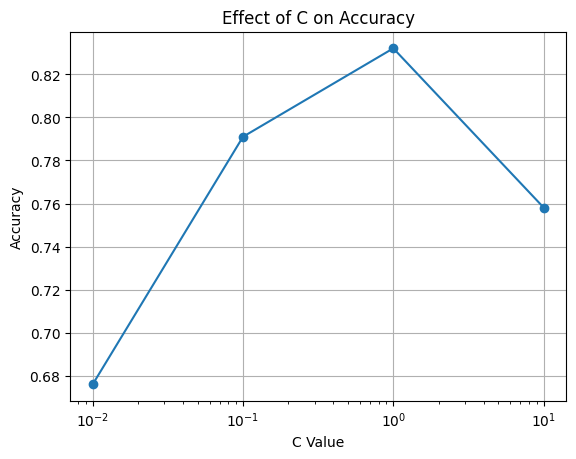

In [ ]:
import matplotlib.pyplot as plt

# Group by C and take mean accuracy
c_results = results.groupby("C")["Accuracy"].mean()

plt.figure()
plt.plot(c_results.index, c_results.values, marker='o')
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("Effect of C on Accuracy")
plt.xscale("log")   # important for C
plt.grid()

plt.show()

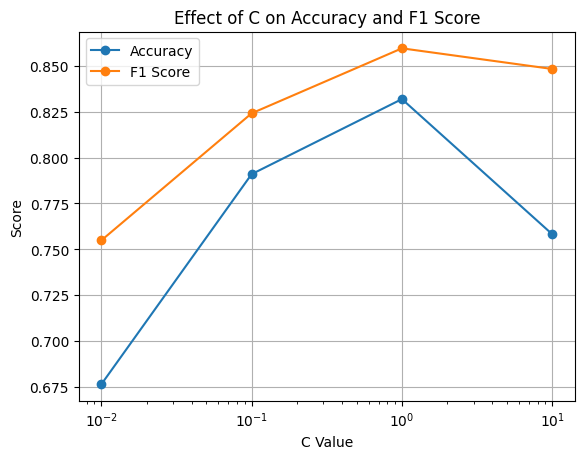

In [ ]:
import matplotlib.pyplot as plt

# Group by C and take mean values
c_results = results.groupby("C")[["Accuracy", "F1_Score"]].mean()

plt.figure()

# Accuracy line
plt.plot(c_results.index, c_results["Accuracy"].values, marker='o', label="Accuracy")

# F1 Score line
plt.plot(c_results.index, c_results["F1_Score"].values, marker='o', label="F1 Score")

plt.xlabel("C Value")
plt.ylabel("Score")
plt.title("Effect of C on Accuracy and F1 Score")
plt.xscale("log")   # important for C
plt.grid()

# Show legend
plt.legend()

plt.show()

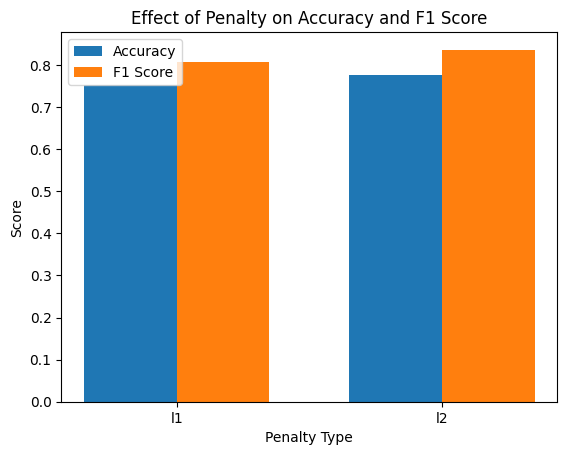

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Group by Penalty and take mean values
penalty_results = results.groupby("Penalty")[["Accuracy", "F1_Score"]].mean()

x = np.arange(len(penalty_results.index))  # positions
width = 0.35  # bar width

plt.figure()

# Accuracy bars
plt.bar(x - width/2, penalty_results["Accuracy"].values, width, label="Accuracy")

# F1 Score bars
plt.bar(x + width/2, penalty_results["F1_Score"].values, width, label="F1 Score")

plt.xlabel("Penalty Type")
plt.ylabel("Score")
plt.title("Effect of Penalty on Accuracy and F1 Score")

plt.xticks(x, penalty_results.index)

# Legend
plt.legend()

plt.show()

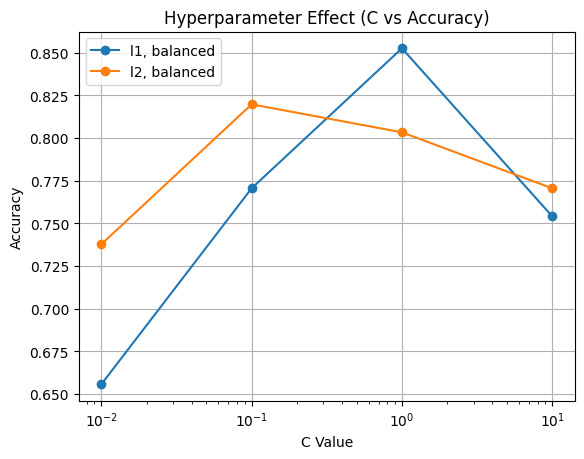

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Unique combinations of penalty and class weight
for (penalty, cw), group in results.groupby(["Penalty", "ClassWeight"]):

    # Average accuracy for each C
    temp = group.groupby("C")["Accuracy"].mean()

    plt.plot(temp.index, temp.values, marker='o', label=f"{penalty}, {cw}")

plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("Hyperparameter Effect (C vs Accuracy)")
plt.xscale("log")
plt.legend()
plt.grid()

plt.show()

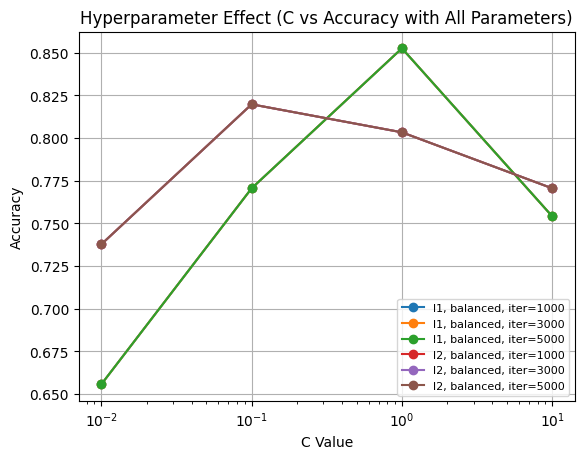

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Loop over all combinations
for (penalty, cw, itr), group in results.groupby(["Penalty", "ClassWeight", "Iterations"]):

    temp = group.groupby("C")["Accuracy"].mean()

    label = f"{penalty}, {cw}, iter={itr}"
    plt.plot(temp.index, temp.values, marker='o', label=label)

plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("Hyperparameter Effect (C vs Accuracy with All Parameters)")
plt.xscale("log")
plt.legend(fontsize=8)
plt.grid()

plt.show()

Random Forest

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "class_weight": [None, "balanced"]
}

In [ ]:
from sklearn.metrics import make_scorer, precision_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

precision_scorer = make_scorer(precision_score)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=precision_scorer
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer # Ensure make_scorer is available
import pandas as pd # Ensure pandas is available

# The 'param_grid' for RandomForestClassifier is defined in cell iEZSoakTakTS.
# The 'grid' object for RandomForestClassifier was defined in cell tIi_jKHhxn4V.
# The global 'results' DataFrame currently holds parameters from the LogisticRegression GridSearchCV.
# To correctly evaluate RandomForestClassifier, we need to fit its GridSearchCV and update 'results'.

# Re-create precision_scorer and grid from previous cells to ensure self-containment
precision_scorer = make_scorer(precision_score, pos_label=1, average='binary') # Assuming pos_label=1 for binary classification

# Assuming 'param_grid' (for RandomForest) is available in the global scope from cell iEZSoakTakTS
# Re-initializing and fitting the GridSearchCV for RandomForestClassifier
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, # This param_grid should be the RandomForest one from iEZSoakTakTS
    cv=5,
    scoring=precision_scorer
)
grid.fit(X_train, y_train) # Fit the RandomForest GridSearchCV

# Now create the results DataFrame from the RandomForest GridSearchCV
results = pd.DataFrame(grid.cv_results_)

# Rename columns for clarity, matching the RandomForest parameters
results = results.rename(columns={
    "param_n_estimators": "N_Estimators",
    "param_max_depth": "Max_Depth",
    "param_min_samples_split": "Min_Samples_Split",
    "param_class_weight": "Class_Weight",
    "mean_test_score": "Precision_Score" # The scoring for this grid is precision_score
})
results["Precision_Score"] = results["Precision_Score"].round(4)

accuracies = []
precisions = []

for params in results["params"]:
    # The 'params' here will now be for RandomForestClassifier (e.g., n_estimators, max_depth)
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, pos_label=1, average='binary')) # Specify pos_label for binary classification

results["Accuracy"] = [round(a, 4) for a in accuracies]
results["Precision"] = [round(p, 4) for p in precisions]


In [ ]:
table = results[[
    "N_Estimators", "Max_Depth", "Min_Samples_Split",
    "Class_Weight", "Accuracy", "Precision"
]]

In [ ]:
table

,N_Estimators,Max_Depth,Min_Samples_Split,Class_Weight,Accuracy,Precision
0,50,5,2,None,0.8033,0.7429
1,100,5,2,None,0.8361,0.7714
2,200,5,2,None,0.8361,0.7714
3,50,5,5,None,0.8197,0.7500
4,100,5,5,None,0.8361,0.7714
5,200,5,5,None,0.8197,0.7500
6,50,5,10,None,0.8197,0.7647
7,100,5,10,None,0.8197,0.7647
8,200,5,10,None,0.8033,0.7429
9,50,10,2,None,0.8361,0.7879


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.metrics import make_scorer, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

# =========================================
# Preprocessing: One-Hot Encode Categorical Features
# =========================================
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)

# =========================================
# 1. Parameter Grid (Important Ones Only)
# =========================================
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "class_weight": [None, "balanced"]
}

# =========================================
# 2. Precision Scorer
# =========================================
precision_scorer = make_scorer(precision_score)

# =========================================
# 3. GridSearchCV
# =========================================
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=precision_scorer,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================================
# 4. Convert Results
# =========================================
results = pd.DataFrame(grid.cv_results_)

results = results.rename(columns={
    "param_n_estimators": "Trees",
    "param_max_depth": "Depth",
    "param_min_samples_split": "Split",
    "param_class_weight": "ClassWeight",
    "mean_test_score": "Precision"
})

results["Precision"] = results["Precision"].round(4)

# =========================================
# 5. Add Accuracy
# =========================================
accuracies = []

for params in results["params"]:
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

results["Accuracy"] = [round(a, 4) for a in accuracies]

# =========================================
# 6. Final Table
# =========================================
table = results[[
    "Trees", "Depth", "Split", "ClassWeight",
    "Accuracy", "Precision"
]]

table = table.sort_values(by="Precision", ascending=False)

print("\n================ FULL RESULT TABLE ================\n")
print(table)

# =========================================
# 7. Comparison Tables (Accuracy + Precision)
# =========================================

# SAME Trees → Effect
pivot_trees = results.pivot_table(
    values=["Accuracy", "Precision"],
    index=["Depth", "Split"],
    columns="Trees"
)

print("\n=== SAME Trees → Effect on Accuracy & Precision ===\n")
print(pivot_trees)

# SAME Depth → Effect
pivot_depth = results.pivot_table(
    values=["Accuracy", "Precision"],
    index=["Trees", "Split"],
    columns="Depth"
)

print("\n=== SAME Depth → Effect on Accuracy & Precision ===\n")
print(pivot_depth)

# SAME Split → Effect
pivot_split = results.pivot_table(
    values=["Accuracy", "Precision"],
    index=["Trees", "Depth"],
    columns="Split"
)

print("\n=== SAME Split → Effect on Accuracy & Precision ===\n")
print(pivot_split)

# FULL COMPARISON TABLE
pivot_full = results.pivot_table(
    values=["Accuracy", "Precision"],
    index=["Trees", "Depth"],
    columns=["ClassWeight", "Split"]
)

print("\n=== FULL COMPARISON TABLE (Accuracy + Precision) ===\n")
print(pivot_full)

# =========================================
# 8. Best Result
# =========================================
print("\n================ BEST RESULT ================\n")
print("Best Parameters:", grid.best_params_)
print("Best Precision (CV):", round(grid.best_score_, 4))

# =========================================
# 9. Final Model Evaluation
# =========================================
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== FINAL MODEL PERFORMANCE ===\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================
# 10. Save All Tables in One Excel Sheet
# =========================================
with pd.ExcelWriter("RandomForest_Results_OneSheet.xlsx") as writer:

    sheet_name = "All Results"
    start_row = 0

    table.to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False)
    start_row += len(table) + 3

    pivot_trees.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_trees) + 5

    pivot_depth.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_depth) + 5

    pivot_split.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_split) + 5

    pivot_full.to_excel(writer, sheet_name=sheet_name, startrow=start_row)

print("\n✅ All tables saved in ONE Excel sheet successfully!")


================ FULL RESULT TABLE ================

    Trees Depth  Split ClassWeight  Accuracy  Precision
42     50    10     10    balanced    0.8361     0.8584
51     50  None     10    balanced    0.8361     0.8584
53    200  None     10    balanced    0.8361     0.8451
44    200    10     10    balanced    0.8361     0.8451
43    100    10     10    balanced    0.8361     0.8440
52    100  None     10    balanced    0.8361     0.8440
35    200     5     10    balanced    0.8197     0.8379
32    200     5      5    balanced    0.8361     0.8378
34    100     5     10    balanced    0.8525     0.8368
2     200     5      2        None    0.8361     0.8367
28    100     5      2    balanced    0.8197     0.8359
33     50     5     10    balanced    0.8361     0.8349
1     100     5      2        None    0.8361     0.8310
23    200  None      5        None    0.8361     0.8265
19    100  None      2        None    0.8361     0.8252
20    200  None      2        None    0.8361     0

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

# Re-initialize X_train and X_test to ensure they are DataFrames
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 1. Preprocessing: One-Hot Encoding
# =========================================
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)

# =========================================
# 2. Feature Selection (Improves Accuracy)
# =========================================
selector = SelectKBest(score_func=f_classif, k=10)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# =========================================
# 3. Parameter Grid (Improved)
# =========================================
param_grid = {
    "n_estimators": [100, 200, 300,400,500],
    "max_depth": [10, 20, None,30,40],
    "min_samples_split": [2, 5,7],
    "min_samples_leaf": [1, 2,4,5,6],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

# =========================================
# 4. Multi-Metric Scoring
# =========================================
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "f1": "f1"
}

# =========================================
# 5. GridSearchCV
# =========================================
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================================
# 6. Convert Results
# =========================================
results = pd.DataFrame(grid.cv_results_)

results = results.rename(columns={
    "param_n_estimators": "Trees",
    "param_max_depth": "Depth",
    "param_min_samples_split": "Split",
    "param_min_samples_leaf": "Leaf",
    "param_max_features": "Features",
    "param_class_weight": "ClassWeight"
})

results["Accuracy"] = results["mean_test_accuracy"].round(4)
results["Precision"] = results["mean_test_precision"].round(4)
results["F1_Score"] = results["mean_test_f1"].round(4)

# =========================================
# 7. Final Table
# =========================================
table = results[[
    "Trees", "Depth", "Split", "Leaf", "Features",
    "ClassWeight", "Accuracy", "Precision", "F1_Score"
]]

table = table.sort_values(by="F1_Score", ascending=False)

print("\n================ FULL RESULT TABLE ================\n")
print(table)

# =========================================
# 8. Comparison Tables
# =========================================

# Trees Effect
pivot_trees = results.pivot_table(
    values=["Accuracy", "Precision", "F1_Score"],
    index=["Depth"],
    columns="Trees"
)

print("\n=== Effect of Trees ===\n")
print(pivot_trees)

# Depth Effect
pivot_depth = results.pivot_table(
    values=["Accuracy", "Precision", "F1_Score"],
    index=["Trees"],
    columns="Depth"
)

print("\n=== Effect of Depth ===\n")
print(pivot_depth)

# Feature Effect
pivot_features = results.pivot_table(
    values=["Accuracy", "Precision", "F1_Score"],
    index=["Trees"],
    columns="Features"
)

print("\n=== Effect of max_features ===\n")
print(pivot_features)

# =========================================
# 9. Best Model
# =========================================
print("\n================ BEST RESULT ================\n")
print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", round(grid.best_score_, 4))

# =========================================
# 10. Final Evaluation
# =========================================
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== FINAL MODEL PERFORMANCE ===\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================
# 11. Save All Tables to Excel
# =========================================
with pd.ExcelWriter("RandomForest_Final_Results.xlsx") as writer:

    sheet_name = "Results"
    start_row = 0

    table.to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False)
    start_row += len(table) + 3

    pivot_trees.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_trees) + 5

    pivot_depth.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_depth) + 5

    pivot_features.to_excel(writer, sheet_name=sheet_name, startrow=start_row)

print("\n✅ All results saved successfully!")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

# Re-initialize X_train and X_test to ensure they are DataFrames
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 1. Preprocessing: One-Hot Encoding
# =========================================
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)

# =========================================
# 2. Feature Selection (Improves Accuracy)
# =========================================
selector = SelectKBest(score_func=f_classif, k=10)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# =========================================
# 3. Parameter Grid (Improved)
# =========================================
param_grid = {
    "n_estimators": [100, 200, 300,400,500],
    "max_depth": [10, 20, None,30,40],
    "min_samples_split": [2, 5,7],
    "min_samples_leaf": [1, 2,4,5,6],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

# =========================================
# 4. Multi-Metric Scoring
# =========================================
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "f1": "f1"
}

# =========================================
# 5. GridSearchCV
# =========================================
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================================
# 6. Convert Results
# =========================================
results = pd.DataFrame(grid.cv_results_)

results = results.rename(columns={
    "param_n_estimators": "Trees",
    "param_max_depth": "Depth",
    "param_min_samples_split": "Split",
    "param_min_samples_leaf": "Leaf",
    "param_max_features": "Features",
    "param_class_weight": "ClassWeight"
})

results["Accuracy"] = results["mean_test_accuracy"].round(4)
results["Precision"] = results["mean_test_precision"].round(4)
results["F1_Score"] = results["mean_test_f1"].round(4)

# =========================================
# 7. Final Table
# =========================================
table = results[[
    "Trees", "Depth", "Split", "Leaf", "Features",
    "ClassWeight", "Accuracy", "Precision", "F1_Score"
]]

table = table.sort_values(by="F1_Score", ascending=False)

print("\n================ FULL RESULT TABLE ================\n")
print(table)

# =========================================
# 8. Comparison Tables
# =========================================

# Trees Effect
pivot_trees = results.pivot_table(
    values=["Accuracy", "Precision", "F1_Score"],
    index=["Depth"],
    columns="Trees"
)

print("\n=== Effect of Trees ===\n")
print(pivot_trees)

# Depth Effect
pivot_depth = results.pivot_table(
    values=["Accuracy", "Precision", "F1_Score"],
    index=["Trees"],
    columns="Depth"
)

print("\n=== Effect of Depth ===\n")
print(pivot_depth)

# Feature Effect
pivot_features = results.pivot_table(
    values=["Accuracy", "Precision", "F1_Score"],
    index=["Trees"],
    columns="Features"
)

print("\n=== Effect of max_features ===\n")
print(pivot_features)

# =========================================
# 9. Best Model
# =========================================
print("\n================ BEST RESULT ================\n")
print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", round(grid.best_score_, 4))

# =========================================
# 10. Final Evaluation
# =========================================
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== FINAL MODEL PERFORMANCE ===\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================
# 11. Save All Tables to Excel
# =========================================
with pd.ExcelWriter("RandomForest_Final_Results.xlsx") as writer:

    sheet_name = "Results"
    start_row = 0

    table.to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False)
    start_row += len(table) + 3

    pivot_trees.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_trees) + 5

    pivot_depth.to_excel(writer, sheet_name=sheet_name, startrow=start_row)
    start_row += len(pivot_depth) + 5

    pivot_features.to_excel(writer, sheet_name=sheet_name, startrow=start_row)

print("\n✅ All results saved successfully!")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

# =========================================
# 1. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 2. One-Hot Encoding
# =========================================
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)

# =========================================
# 3. Feature Selection
# =========================================
selector = SelectKBest(score_func=f_classif, k=10)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# =========================================
# 4. IMPROVED PARAM GRID
# =========================================
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],

    # 🔥 Newly added important parameters
    "criterion": ["gini", "entropy"],
    "bootstrap": [True, False],
    "ccp_alpha": [0.0, 0.01]
}

# =========================================
# 5. Multi-Metric Scoring
# =========================================
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "f1": "f1"
}

# =========================================
# 6. GridSearchCV
# =========================================
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================================
# 7. Convert Results
# =========================================
results = pd.DataFrame(grid.cv_results_)

results = results.rename(columns={
    "param_n_estimators": "Trees",
    "param_max_depth": "Depth",
    "param_min_samples_split": "Split",
    "param_min_samples_leaf": "Leaf",
    "param_max_features": "Features",
    "param_class_weight": "ClassWeight",
    "param_criterion": "Criterion",
    "param_bootstrap": "Bootstrap",
    "param_ccp_alpha": "Pruning"
})

results["Accuracy"] = results["mean_test_accuracy"].round(4)
results["Precision"] = results["mean_test_precision"].round(4)
results["F1_Score"] = results["mean_test_f1"].round(4)

# =========================================
# 8. Final Table
# =========================================
table = results[[
    "Trees", "Depth", "Split", "Leaf", "Features",
    "ClassWeight", "Criterion", "Bootstrap", "Pruning",
    "Accuracy", "Precision", "F1_Score"
]]

table = table.sort_values(by="F1_Score", ascending=False)

print("\n================ FULL RESULT TABLE ================\n")
print(table)

# =========================================
# 9. Best Model
# =========================================
print("\n================ BEST RESULT ================\n")
print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", round(grid.best_score_, 4))

# =========================================
# 10. Final Evaluation
# =========================================
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== FINAL MODEL PERFORMANCE ===\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================
# 11. Save Results
# =========================================
with pd.ExcelWriter("RandomForest_Final_Results.xlsx") as writer:
    table.to_excel(writer, sheet_name="Results", index=False)

print("\n✅ All results saved successfully!")

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

# =========================================
# 1. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 2. One-Hot Encoding
# =========================================
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)

# =========================================
# 3. Feature Selection
# =========================================
selector = SelectKBest(score_func=f_classif, k=10)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# =========================================
# 4. PARAM GRID (SVM HYPERPARAMETERS)
# =========================================
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"],
    "degree": [2, 3, 4],   # used only for poly kernel
    "class_weight": [None, "balanced"]
}

# =========================================
# 5. MULTI-METRIC SCORING
# =========================================
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "f1": "f1"
}

# =========================================
# 6. GRID SEARCH CV
# =========================================
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================================
# 7. Convert Results
# =========================================
results = pd.DataFrame(grid.cv_results_)

results = results.rename(columns={
    "param_C": "C_Value",
    "param_kernel": "Kernel",
    "param_gamma": "Gamma",
    "param_degree": "Degree",
    "param_class_weight": "ClassWeight"
})

results["Accuracy"] = results["mean_test_accuracy"].round(4)
results["Precision"] = results["mean_test_precision"].round(4)
results["F1_Score"] = results["mean_test_f1"].round(4)

# =========================================
# 8. FINAL RESULT TABLE
# =========================================
table = results[[
    "C_Value", "Kernel", "Gamma", "Degree", "ClassWeight",
    "Accuracy", "Precision", "F1_Score"
]]

table = table.sort_values(by="F1_Score", ascending=False)

print("\n================ FULL RESULT TABLE ================\n")
print(table)

# =========================================
# 9. BEST MODEL
# =========================================
print("\n================ BEST RESULT ================\n")
print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", round(grid.best_score_, 4))

# =========================================
# 10. FINAL EVALUATION
# =========================================
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== FINAL MODEL PERFORMANCE ===\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================
# 11. SAVE RESULTS
# =========================================
with pd.ExcelWriter("SVM_Final_Results.xlsx") as writer:
    table.to_excel(writer, sheet_name="Results", index=False)

print("\n✅ All results saved successfully!")